In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from random_forest_classifier import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix 

In [9]:
df= sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [10]:
#extracting x and y
X= df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y= df['species'].values

In [11]:
#splitting train test data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size= 0.2)

In [12]:
#Printing shapes
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)


In [13]:
le= LabelEncoder()
y_train_encoded= le.fit_transform(y_train).reshape(-1, 1)

In [14]:
#training
dt= RandomForestClassifier(n_estimators= 10 ,min_samples_split = 5, max_depth= 4)
dt.fit(X_train, y_train_encoded)

In [15]:
#predicting
y_pred_encoded= [int(x) for x in dt.predict(X_test)]
y_pred= le.inverse_transform(y_pred_encoded)

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



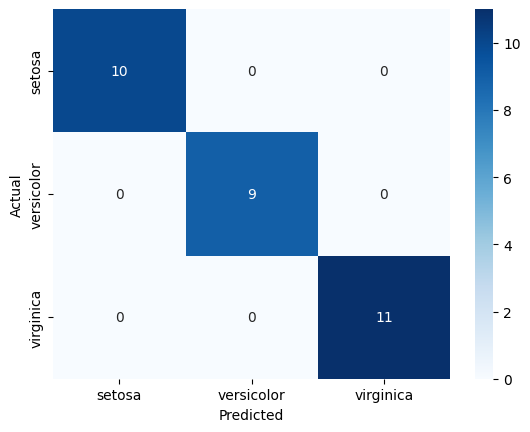

In [17]:
#confusion matrix plot

label_order= np.unique(np.concatenate([y_test, y_pred]))
cm= confusion_matrix(y_test, y_pred, labels= label_order)
sns.heatmap(cm, cbar= True, cmap= 'Blues', annot= True, xticklabels= label_order, yticklabels= label_order)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()